In [11]:
get_ipython().system('pip install psycopg2-binary sqlalchemy -q')
print("Packages ready")

Packages ready


In [12]:
from google.colab import drive
import sys
drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/Chronos_ML')
import preprocess

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split, cross_val_score, LeaveOneOut
from sklearn.pipeline          import Pipeline
from sklearn.preprocessing     import StandardScaler, OrdinalEncoder
from sklearn.impute             import SimpleImputer
from sklearn.compose           import ColumnTransformer
from sklearn.ensemble          import (RandomForestClassifier,
                                       GradientBoostingClassifier,
                                       RandomForestRegressor,
                                       GradientBoostingRegressor)
from sklearn.linear_model      import LogisticRegression, Ridge
from sklearn.metrics           import (classification_report, confusion_matrix,
                                       ConfusionMatrixDisplay, roc_auc_score,
                                       roc_curve, mean_squared_error, r2_score)

# Import our own preprocessing module
from preprocess import run_full_pipeline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print("All imports done")

All imports done


In [14]:
from google.colab import drive
import sys

# Ensure Google Drive is mounted and the path is added before importing preprocess
if '/content/drive' not in sys.path:
    drive.mount('/content/drive')
if '/content/drive/MyDrive/Chronos_ML' not in sys.path:
    sys.path.append('/content/drive/MyDrive/Chronos_ML')

from preprocess import run_full_pipeline

CONNECTION_STRING = (
    "postgresql://neondb_owner:npg_9TWHDOPnmg2J"
    "@ep-royal-frost-ahqo694y-pooler.c-3.us-east-1.aws.neon.tech"
    "/neondb?sslmode=require&channel_binding=require"
)

df, NUMERIC_FEATURES, CATEGORICAL_FEATURES, ALL_FEATURES, outlier_report = \
    run_full_pipeline(CONNECTION_STRING)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  chronos_ml — Preprocessing Pipeline
[load_data] Loaded 100 rows × 51 columns from Neon
[clean_data] Done — 100 rows × 44 columns
[remove_outliers] Capped outliers in 10 columns
[engineer_features] Created 11 new features: ['log_total_train_rows', 'log_n_estimators', 'lr_x_epochs', 'data_richness', 'feature_density', 'dataset_complexity_score', 'hp_completeness', 'is_deep_learning', 'is_ensemble', 'is_business_hours', 'is_weekend']
[get_feature_lists] 39 numeric + 6 categorical = 45 total features

  Final shape : (100, 55)
  Total feats : 45


In [15]:
print(f"\nDataFrame shape  : {df.shape}")
print(f"Numeric features : {len(NUMERIC_FEATURES)}")
print(f"Cat features     : {len(CATEGORICAL_FEATURES)}")
print(f"\nFirst 5 rows:")
df.sample(5)


DataFrame shape  : (100, 55)
Numeric features : 39
Cat features     : 6

First 5 rows:


,category,problem_type,license_type,is_public,algorithm,version_status,run_success,duration_hours,start_hour,start_day_of_week,...,log_n_estimators,lr_x_epochs,data_richness,feature_density,dataset_complexity_score,hp_completeness,is_deep_learning,is_ensemble,is_business_hours,is_weekend
90,deep learning,object detection,gpl-3.0,0,yolov8 medium checkpoint,production,1,1.7894,12.0,6.0,...,0.0,0.0,0.000000,0.0,0.0000,0.285714,1,0,1,1
59,deep learning,object detection,gpl-3.0,0,yolov8 medium checkpoint,production,0,0.1650,8.0,1.0,...,0.0,0.0,0.000000,0.0,0.0000,0.285714,1,0,0,0
23,other,other,gpl-3.0,1,heuristic evolutionary matrix v1,production,0,0.0667,8.0,3.0,...,0.0,0.0,14.709008,2.0,36.5569,0.285714,0,0,0,0
12,semi-supervised learning,classification,other,0,label spreading rbf kernel run,archived,1,1.7500,14.0,6.0,...,0.0,0.0,14.709008,2.0,36.5569,0.285714,0,0,1,1
52,deep learning,object detection,gpl-3.0,0,yolov8 medium checkpoint,production,1,7.0050,4.0,0.0,...,0.0,0.0,0.000000,0.0,0.0000,0.285714,1,0,0,1


In [16]:
print("Target Distribution")
print(df['run_success'].value_counts())
print()
print("Numeric Features — Summary Stats")
print(df[NUMERIC_FEATURES].describe().round(3).T
      [['mean','std','min','50%','max']].to_string())

Target Distribution
run_success
1    65
0    35
Name: count, dtype: int64

Numeric Features — Summary Stats
                            mean     std     min     50%      max
learning_rate              0.195   0.179   0.000   0.173    0.688
n_estimators                 NaN     NaN     NaN     NaN      NaN
max_depth                    NaN     NaN     NaN     NaN      NaN
batch_size                95.360  85.814  16.000  64.000  272.000
epochs                       NaN     NaN     NaN     NaN      NaN
num_leaves                   NaN     NaN     NaN     NaN      NaN
subsample                    NaN     NaN     NaN     NaN      NaN
dropout                      NaN     NaN     NaN     NaN      NaN
weight_decay                 NaN     NaN     NaN     NaN      NaN
warmup_steps                 NaN     NaN     NaN     NaN      NaN
n_clusters                   NaN     NaN     NaN     NaN      NaN
gamma                        NaN     NaN     NaN     NaN      NaN
clip_range                   NaN  

In [17]:
rpt_df = pd.DataFrame(outlier_report).T
print("Outlier Capping Report")
rpt_df

Outlier Capping Report


,lower_fence,upper_fence,outliers_capped
learning_rate,-0.3453,0.6875,6.0
n_estimators,NaN,NaN,0.0
max_depth,NaN,NaN,0.0
batch_size,-112.0000,272.0000,12.0
epochs,NaN,NaN,0.0
total_train_rows,-5587.5000,9312.5000,25.0
duration_hours,-8.4606,14.5444,0.0
artifact_size_gb,0.0000,0.0000,20.0
user_total_runs,-96.5000,171.5000,0.0
total_snapshots,1.0000,1.0000,0.0


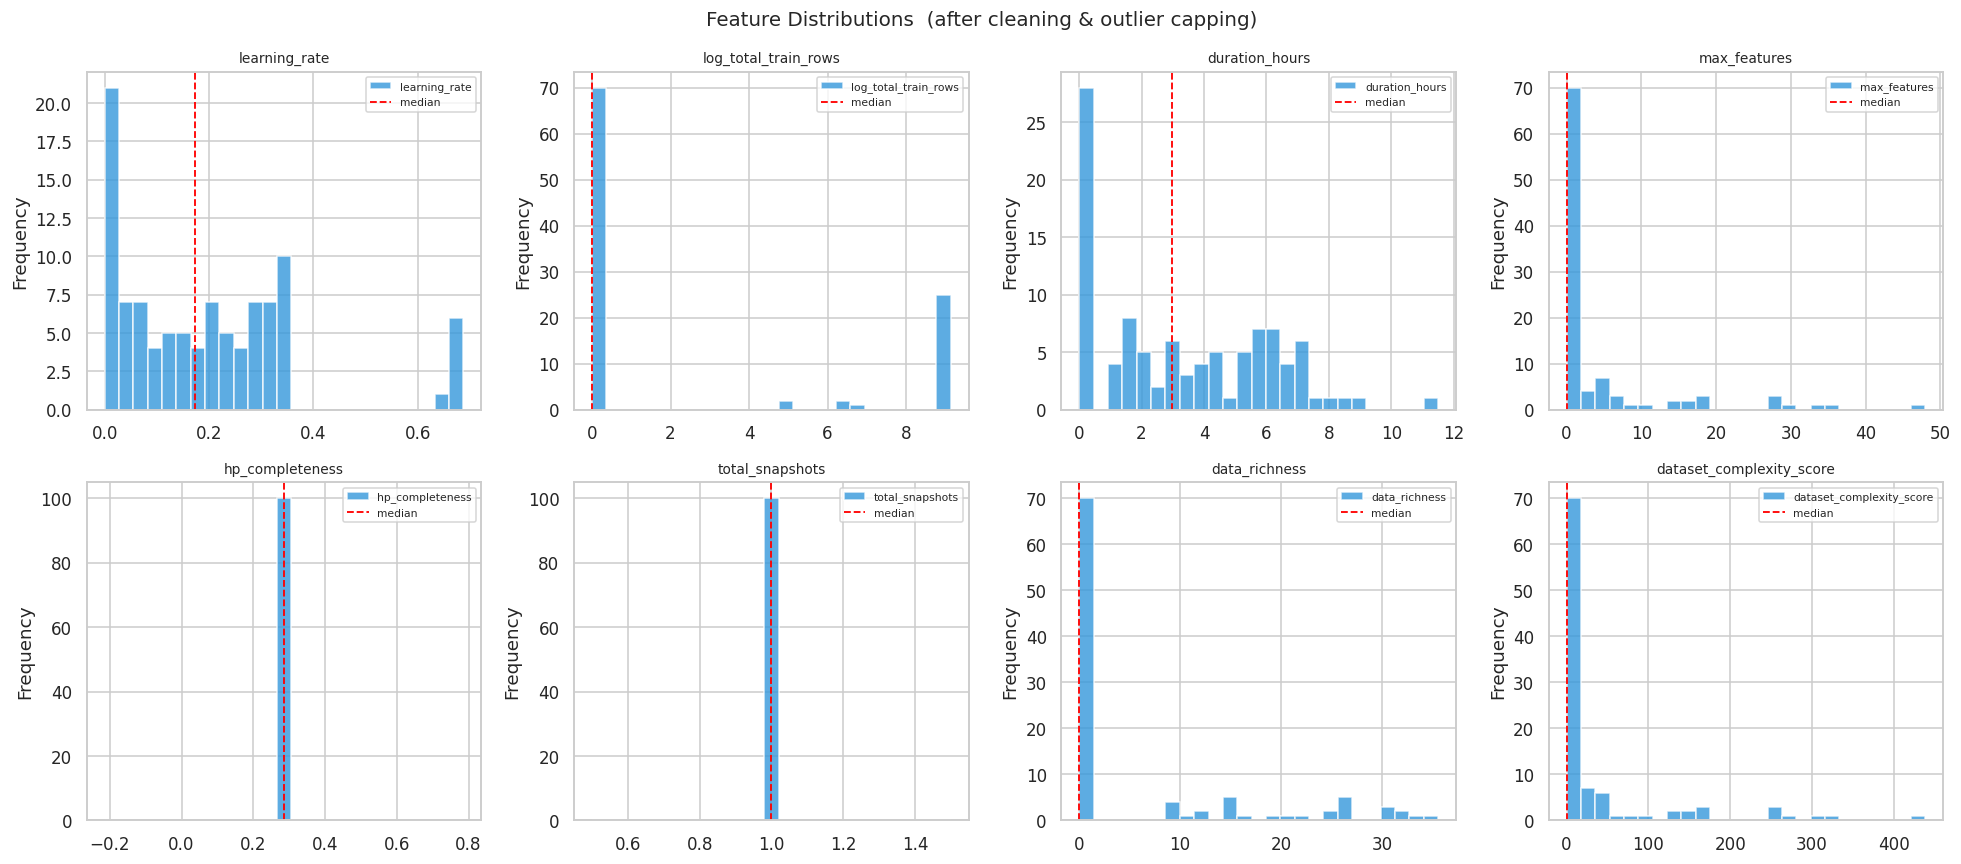

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

plot_cols = [c for c in ['learning_rate', 'log_total_train_rows',
                          'duration_hours', 'max_features',
                          'hp_completeness', 'total_snapshots',
                          'data_richness', 'dataset_complexity_score']
             if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Feature Distributions  (after cleaning & outlier capping)', fontsize=13)

for i, col in enumerate(plot_cols[:8]):
    ax = axes[i // 4][i % 4]
    df[col].dropna().plot(kind='hist', bins=25, ax=ax,
                          color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(df[col].median(), color='red', linestyle='--',
               linewidth=1.2, label='median')
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

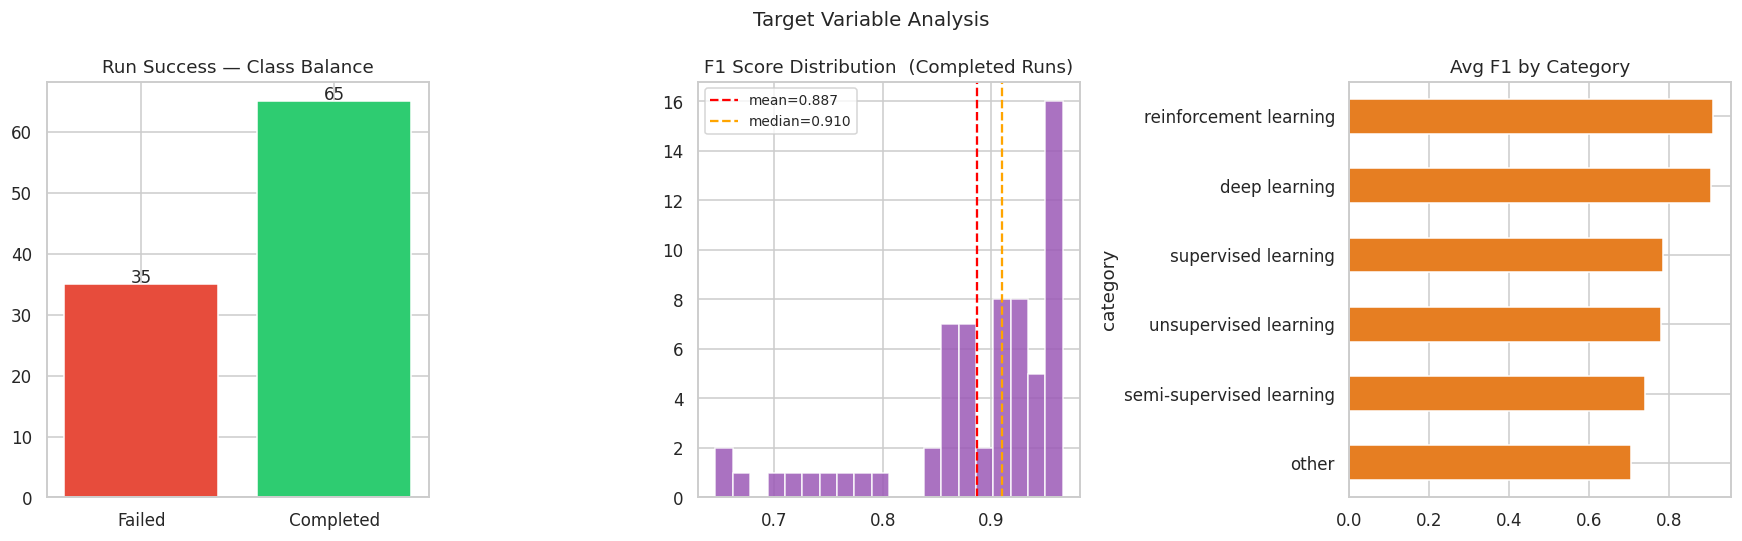

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Target Variable Analysis', fontsize=13)

counts = df['run_success'].value_counts()
axes[0].bar(['Failed', 'Completed'],
            [counts.get(0,0), counts.get(1,0)],
            color=['#e74c3c','#2ecc71'])
axes[0].set_title('Run Success — Class Balance')
for bar, val in zip(axes[0].patches, [counts.get(0,0), counts.get(1,0)]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3, str(val), ha='center', fontsize=11)


completed = df[df['run_success']==1]['final_f1'].dropna()
axes[1].hist(completed, bins=20, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].axvline(completed.mean(),   color='red',    linestyle='--',
                label=f'mean={completed.mean():.3f}')
axes[1].axvline(completed.median(), color='orange', linestyle='--',
                label=f'median={completed.median():.3f}')
axes[1].set_title('F1 Score Distribution  (Completed Runs)')
axes[1].legend(fontsize=9)

df_c = df[df['run_success']==1]
if 'category' in df_c.columns:
    df_c.groupby('category')['final_f1'].mean().sort_values().plot(
        kind='barh', ax=axes[2], color='#e67e22')
axes[2].set_title('Avg F1 by Category')

plt.tight_layout()
plt.show()

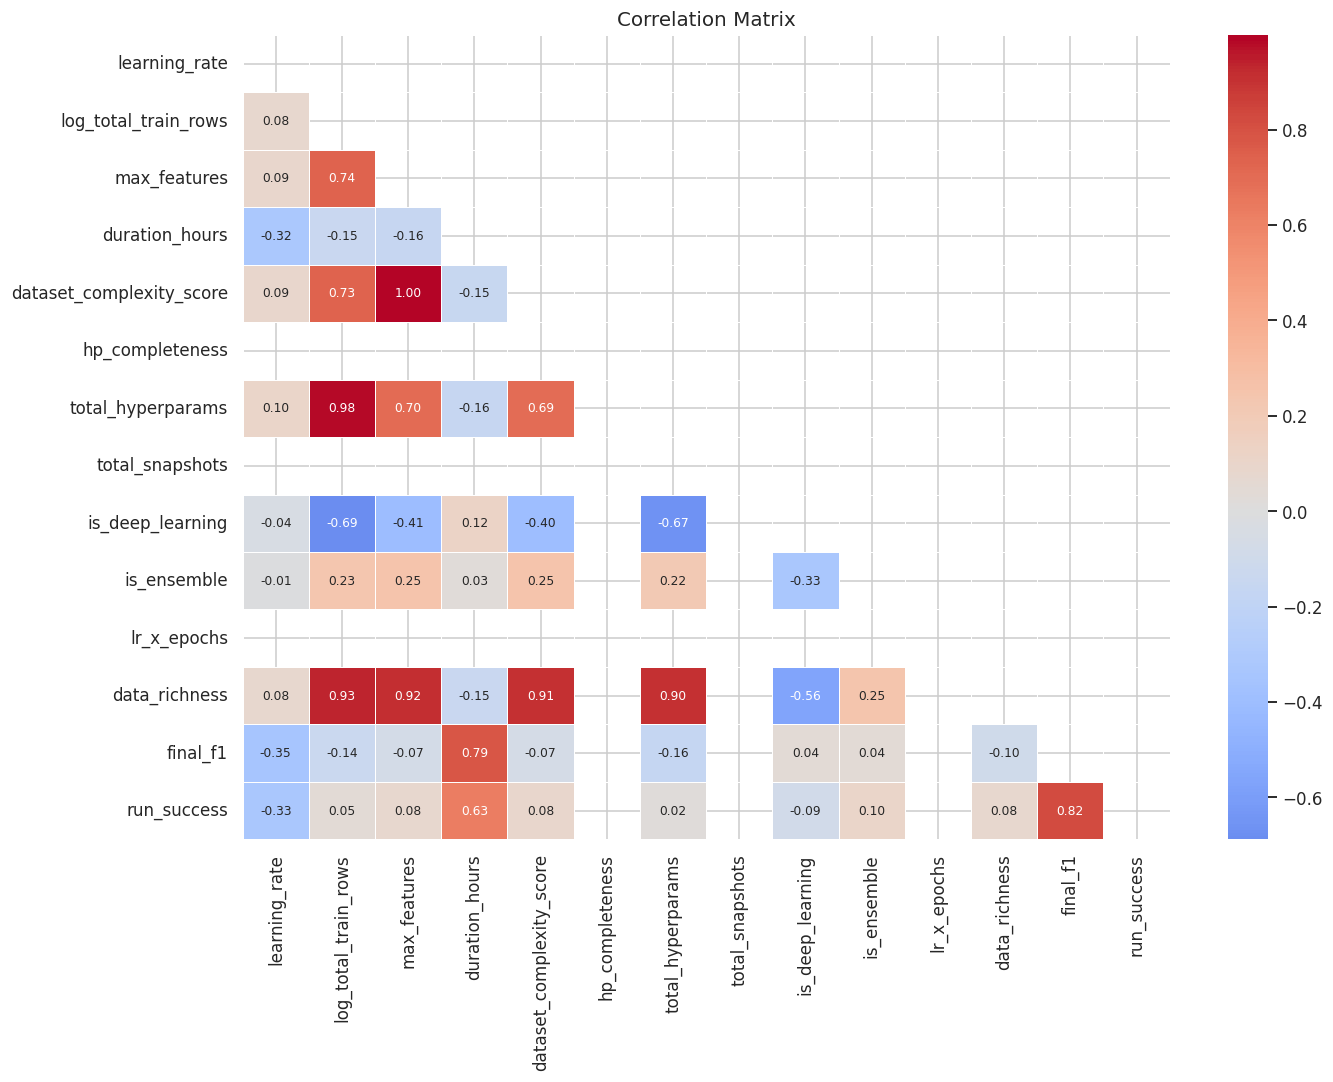


Top correlations with final_f1:
run_success                 0.823955
duration_hours              0.785213
learning_rate               0.350485
total_hyperparams           0.162259
log_total_train_rows        0.137152
data_richness               0.100637
max_features                0.072781
dataset_complexity_score    0.066549


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

CORR_COLS = [c for c in [
    'learning_rate', 'log_total_train_rows', 'max_features',
    'duration_hours', 'dataset_complexity_score', 'hp_completeness',
    'total_hyperparams', 'total_snapshots', 'is_deep_learning',
    'is_ensemble', 'lr_x_epochs', 'data_richness',
    'final_f1', 'run_success'
] if c in df.columns]

corr = df[CORR_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(13, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop correlations with final_f1:")
if 'final_f1' in corr.columns:
    print(corr['final_f1'].drop('final_f1').abs()
          .sort_values(ascending=False).head(8).to_string())

In [21]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value',
                               unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

print("Preprocessor ready")

Preprocessor ready


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_clf = df[ALL_FEATURES].copy()
y_clf = df['run_success'].copy()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Task B — Regression (predict final_f1, completed runs only)
df_reg = df[df['run_success']==1].dropna(subset=['final_f1'])
X_reg  = df_reg[ALL_FEATURES].copy()
y_reg  = df_reg['final_f1'].copy()

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Classification — Train:{X_train_c.shape}  Test:{X_test_c.shape}")
print(f"Class balance  — 0:{(y_train_c==0).sum()}  1:{(y_train_c==1).sum()}")
print(f"\nRegression     — Train:{X_train_r.shape}  Test:{X_test_r.shape}")
print(f"F1 range       — min:{y_reg.min():.4f}  max:{y_reg.max():.4f}")

Classification — Train:(80, 45)  Test:(20, 45)
Class balance  — 0:28  1:52

Regression     — Train:(52, 45)  Test:(13, 45)
F1 range       — min:0.6460  max:0.9658


In [23]:
clf_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   min_samples_leaf=2,
                                                   random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200,
                                                        learning_rate=0.05,
                                                        max_depth=4,
                                                        random_state=42),
}

clf_results  = []
clf_pipelines = {}

for name, model in clf_models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train_c, y_train_c)

    y_pred = pipe.predict(X_test_c)
    y_prob = pipe.predict_proba(X_test_c)[:, 1]
    cv     = cross_val_score(pipe, X_clf, y_clf, cv=5, scoring='f1')
    auc    = roc_auc_score(y_test_c, y_prob)

    clf_pipelines[name] = pipe
    clf_results.append({
        'Model'       : name,
        'CV_F1_Mean'  : round(cv.mean(), 4),
        'CV_F1_Std'   : round(cv.std(),  4),
        'ROC_AUC'     : round(auc, 4),
    })
    print(f"  {name:<25}  CV-F1={cv.mean():.4f}±{cv.std():.4f}  AUC={auc:.4f}")

clf_df = pd.DataFrame(clf_results).sort_values('CV_F1_Mean', ascending=False)
print(f"\nBest classifier → {clf_df.iloc[0]['Model']}")

  Logistic Regression        CV-F1=0.8415±0.1021  AUC=0.9560
  Random Forest              CV-F1=0.9243±0.0571  AUC=1.0000
  Gradient Boosting          CV-F1=0.8951±0.0906  AUC=1.0000

Best classifier → Random Forest


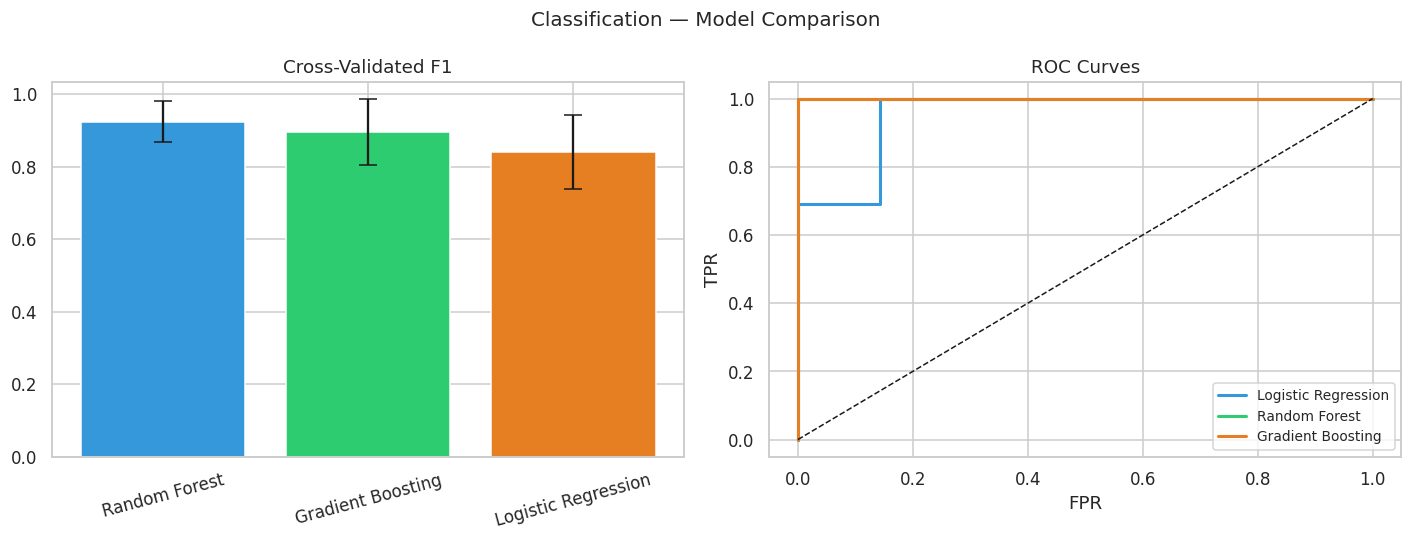

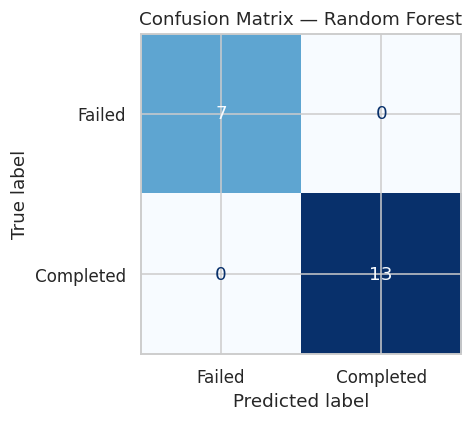

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Classification — Model Comparison', fontsize=13)

axes[0].bar(clf_df['Model'], clf_df['CV_F1_Mean'],
            yerr=clf_df['CV_F1_Std'], capsize=6,
            color=['#3498db','#2ecc71','#e67e22'][:len(clf_df)])
axes[0].set_title('Cross-Validated F1')
axes[0].tick_params(axis='x', rotation=15)

for name, color in zip(clf_models.keys(), ['#3498db','#2ecc71','#e67e22']):
    pipe   = clf_pipelines[name]
    y_prob = pipe.predict_proba(X_test_c)[:,1]
    fpr, tpr, _ = roc_curve(y_test_c, y_prob)
    axes[1].plot(fpr, tpr, label=name, color=color, lw=2)
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_title('ROC Curves')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Confusion matrix for best classifier
BEST_CLF_NAME = clf_df.iloc[0]['Model']
BEST_CLF_PIPE = clf_pipelines[BEST_CLF_NAME]
y_pred_best   = BEST_CLF_PIPE.predict(X_test_c)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test_c, y_pred_best),
                       display_labels=['Failed','Completed']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {BEST_CLF_NAME}')
plt.tight_layout()
plt.show()

In [25]:
corr_target = df_reg[NUMERIC_FEATURES].corrwith(df_reg['final_f1']).abs()
top_num     = corr_target.sort_values(ascending=False).head(8).index.tolist()
top_cat     = [c for c in CATEGORICAL_FEATURES if c in df_reg.columns]
TOP_REG_FEATURES = top_num + top_cat

print("Top numeric features for regression:")
for i, f in enumerate(top_num, 1):
    print(f"  {i}. {f}  (|corr|={corr_target[f]:.4f})")

# Rebuild preprocessor for reduced feature set
pre_reg = ColumnTransformer(transformers=[
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]),
     top_num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('enc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                             unknown_value=-1))]),
     top_cat)
])

X_reg_top    = df_reg[TOP_REG_FEATURES]
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_reg_top, y_reg, test_size=0.2, random_state=42
)


Top numeric features for regression:
  1. batch_size  (|corr|=0.7183)
  2. duration_hours  (|corr|=0.5955)
  3. data_richness  (|corr|=0.5799)
  4. user_total_runs  (|corr|=0.5788)
  5. log_total_train_rows  (|corr|=0.5631)
  6. dataset_count  (|corr|=0.5410)
  7. total_hyperparams  (|corr|=0.5410)
  8. dataset_complexity_score  (|corr|=0.5398)


In [26]:

reg_models = {
    'Ridge Regression'  : Ridge(alpha=10.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, max_depth=4,
                                                min_samples_leaf=3, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, learning_rate=0.05,
                                                     max_depth=3, random_state=42),
}

reg_results   = []
reg_pipelines = {}
loo           = LeaveOneOut()

for name, model in reg_models.items():
    pipe = Pipeline(steps=[('preprocessor', pre_reg), ('model', model)])
    pipe.fit(X_tr2, y_tr2)
    preds    = pipe.predict(X_te2)
    rmse     = round(np.sqrt(mean_squared_error(y_te2, preds)), 4)
    r2       = round(r2_score(y_te2, preds), 4)
    loo_sc   = cross_val_score(pipe, X_reg_top, y_reg, cv=loo, scoring='r2')

    reg_pipelines[name] = pipe
    reg_results.append({
        'Model'       : name,
        'RMSE'        : rmse,
        'R2_test'     : r2,
        'LOO_R2_mean' : round(loo_sc.mean(), 4),
        'LOO_R2_std'  : round(loo_sc.std(),  4),
    })
    print(f"  {name:<22}  RMSE={rmse}  R²={r2}  LOO-R²={loo_sc.mean():.4f}")

reg_df       = pd.DataFrame(reg_results).sort_values('R2_test', ascending=False)
BEST_REG_NAME = reg_df.iloc[0]['Model']
BEST_REG_PIPE = reg_pipelines[BEST_REG_NAME]
print(f"\nBest regressor → {BEST_REG_NAME}")

  Ridge Regression        RMSE=0.0506  R²=0.5897  LOO-R²=nan
  Random Forest           RMSE=0.0477  R²=0.6342  LOO-R²=nan
  Gradient Boosting       RMSE=0.0538  R²=0.5361  LOO-R²=nan

Best regressor → Random Forest


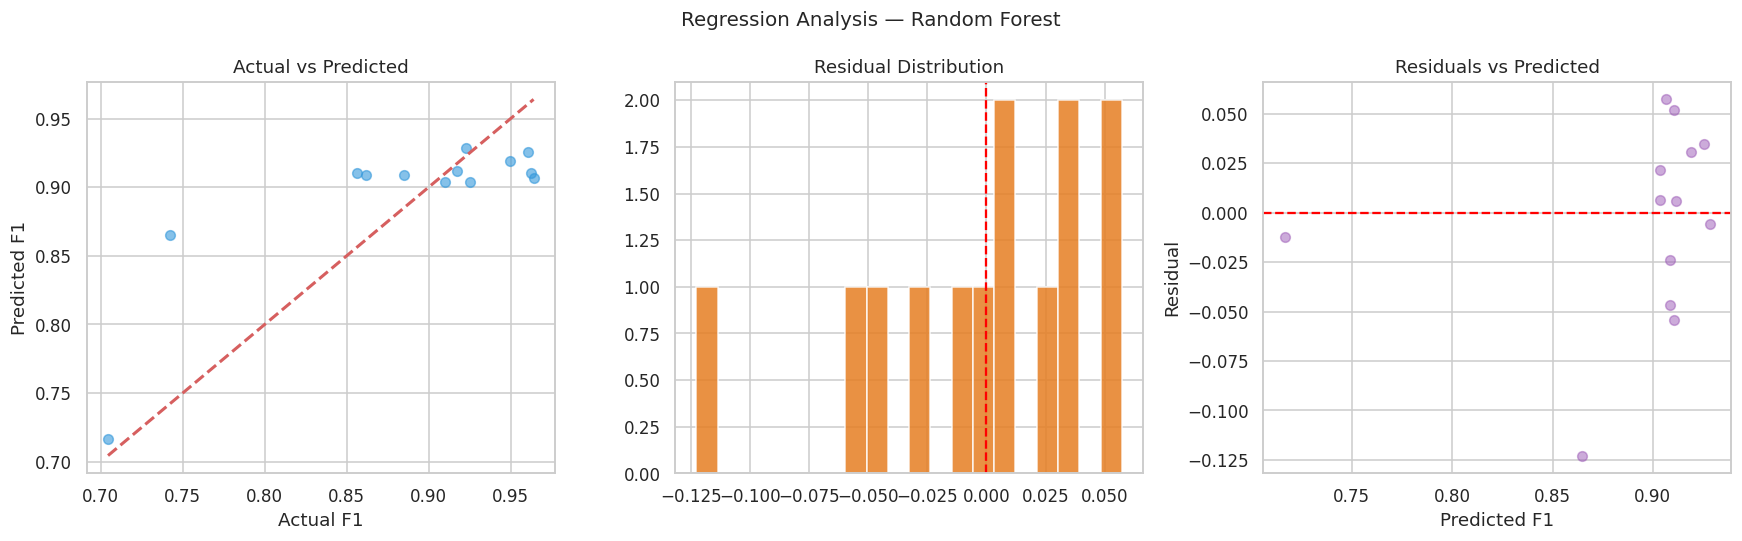


Final RMSE : 0.0477
Final R²   : 0.6342


In [27]:
best_preds = BEST_REG_PIPE.predict(X_te2)
residuals  = y_te2 - best_preds

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Regression Analysis — {BEST_REG_NAME}', fontsize=13)

axes[0].scatter(y_te2, best_preds, alpha=0.6, color='#3498db', s=40)
mn, mx = y_te2.min(), y_te2.max()
axes[0].plot([mn,mx],[mn,mx],'r--', lw=2)
axes[0].set_xlabel('Actual F1')
axes[0].set_ylabel('Predicted F1')
axes[0].set_title('Actual vs Predicted')

axes[1].hist(residuals, bins=20, color='#e67e22', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution')

axes[2].scatter(best_preds, residuals, alpha=0.5, color='#9b59b6', s=40)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Predicted F1')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

rmse_f = np.sqrt(mean_squared_error(y_te2, best_preds))
r2_f   = r2_score(y_te2, best_preds)
print(f"\nFinal RMSE : {rmse_f:.4f}")
print(f"Final R²   : {r2_f:.4f}")

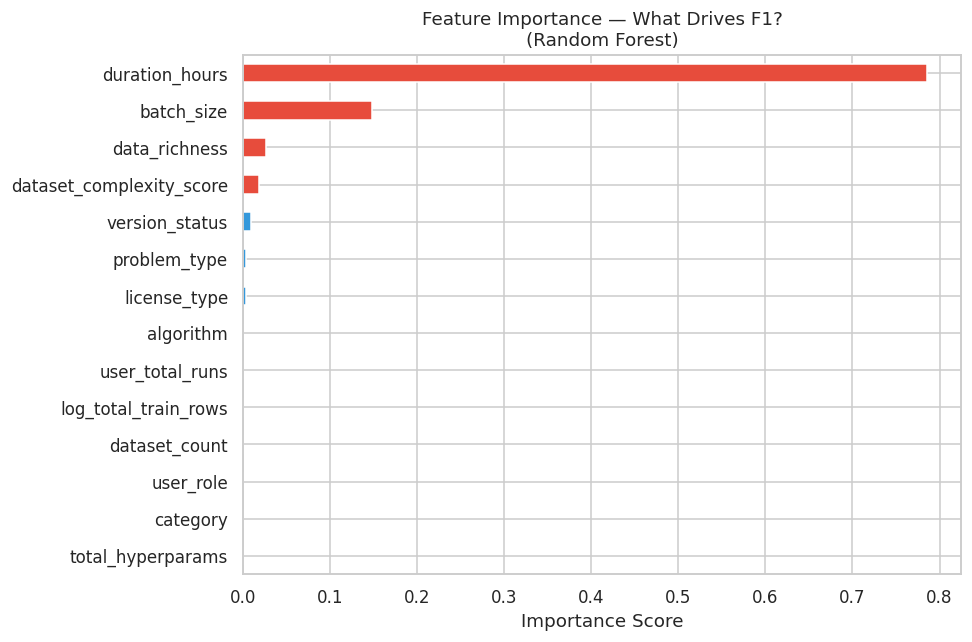

=== Top 5 Features driving F1 ===
                 feature  importance_score  rank        method
          duration_hours          0.785817     1 gini_impurity
              batch_size          0.148400     2 gini_impurity
           data_richness          0.027105     3 gini_impurity
dataset_complexity_score          0.019337     4 gini_impurity
          version_status          0.009224     5 gini_impurity


In [28]:
best_step = BEST_REG_PIPE.named_steps['model']
if hasattr(best_step, 'feature_importances_'):
    importances = pd.Series(
        best_step.feature_importances_,
        index=TOP_REG_FEATURES
    ).sort_values(ascending=True)

    plt.figure(figsize=(9, 6))
    colors = ['#e74c3c' if v > importances.quantile(0.75) else '#3498db'
              for v in importances]
    importances.plot(kind='barh', color=colors)
    plt.title(f'Feature Importance — What Drives F1?\n({BEST_REG_NAME})', fontsize=12)
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    imp_df = importances.sort_values(ascending=False).reset_index()
    imp_df.columns = ['feature','importance_score']
    imp_df['rank']   = range(1, len(imp_df)+1)
    imp_df['method'] = 'gini_impurity'

    print("=== Top 5 Features driving F1 ===")
    print(imp_df.head(5).to_string(index=False))
    imp_df.to_csv('feature_importance.csv', index=False)

In [29]:
from google.colab import drive
import joblib
import os

# Mount Drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/Chronos_ML'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save files
joblib.dump(BEST_CLF_PIPE,    os.path.join(SAVE_DIR, 'best_classifier.pkl'))
joblib.dump(BEST_REG_PIPE,    os.path.join(SAVE_DIR, 'best_regressor.pkl'))
joblib.dump(ALL_FEATURES,     os.path.join(SAVE_DIR, 'all_feature_names.pkl'))
joblib.dump(TOP_REG_FEATURES, os.path.join(SAVE_DIR, 'reg_feature_names.pkl'))
joblib.dump(BEST_CLF_NAME,    os.path.join(SAVE_DIR, 'best_clf_name.pkl'))
joblib.dump(BEST_REG_NAME,    os.path.join(SAVE_DIR, 'best_reg_name.pkl'))

# Save feature importance CSV if it exists
try:
    feature_importance.to_csv(
        os.path.join(SAVE_DIR, 'feature_importance.csv'),
        index=False
    )
except:
    pass

print(f"Saved all files to: {SAVE_DIR}")

print("\nFiles present:")
for f in os.listdir(SAVE_DIR):
    print(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved all files to: /content/drive/MyDrive/Chronos_ML

Files present:
preprocess.py
__pycache__
best_classifier.pkl
best_regressor.pkl
all_feature_names.pkl
reg_feature_names.pkl
best_clf_name.pkl
best_reg_name.pkl
